# Wheat Plant Disease Classification: Comparative Study

This notebook compares transfer learning performance of VGG16, MobileNetV2, and ResNet50 on the Kaggle Wheat Plant Diseases dataset, using accuracy, precision, recall, and F1-score.


## Setup

Requirements
- Python 3.9+
- TensorFlow 2.13+
- scikit-learn, pandas, matplotlib, seaborn
- Kaggle API credentials

Install dependencies
- `pip install -r requirements.txt`

Kaggle credentials
1. Create a Kaggle API token (kaggle.json).
2. Place it at ~/.kaggle/kaggle.json or set environment variables KAGGLE_USERNAME and KAGGLE_KEY.


In [4]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight


## Training Strategy

We use each pretrained CNN as a fixed feature extractor (base frozen).
Only the custom classifier head is trained; base weights are not updated.

Resume option: set `RESUME_FROM_CHECKPOINT = True` to continue training from saved checkpoints in `artifacts/`.

Key hyperparameters to tune if needed: `INITIAL_EPOCHS`, `INITIAL_LR`, `PATIENCE`.


In [5]:
SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32

# Training hyperparameters (feature extractor; base frozen)
INITIAL_EPOCHS = 50
INITIAL_LR = 1e-3
PATIENCE = 10
RESUME_FROM_CHECKPOINT = True  # set True to continue training from saved checkpoints
AUTOTUNE = tf.data.AUTOTUNE

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed()

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print('Could not set memory growth:', exc)


TensorFlow: 2.21.0
GPUs: []


In [7]:
import json

DATA_DIR = Path(r"C:\Users\it\Desktop\New folder (6)\wheats\data")
DATA_ROOT = DATA_DIR / 'Wheat Disease Dataset'

def get_data_root():
    if DATA_ROOT.exists():
        return DATA_ROOT
    return find_image_root(DATA_DIR)


try:
    data_root = get_data_root()
    print('Data directory already populated:', data_root.resolve())
except FileNotFoundError:
    raise FileNotFoundError(
        'No dataset found under data/. Place your dataset folder under data/Wheat Disease Dataset.'
    )

Data directory already populated: C:\Users\it\Desktop\New folder (6)\wheats\data\Wheat Disease Dataset


In [8]:
import json
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.jfif'}

def has_images(path):
    return any(p.suffix.lower() in IMAGE_EXTS for p in path.iterdir() if p.is_file())

def find_image_root(base_dir):
    base_dir = Path(base_dir)
    for p in [base_dir] + list(base_dir.rglob('*')):
        if not p.is_dir():
            continue
        subdirs = [d for d in p.iterdir() if d.is_dir() and d.name.lower() != 'augmented']
        if not subdirs:
            continue
        if all(has_images(d) for d in subdirs):
            return p
    raise FileNotFoundError('Could not find an image root with class subfolders.')

data_root = DATA_ROOT if DATA_ROOT.exists() else find_image_root(DATA_DIR)
print('Image root:', data_root)

merge_map = {
    # Keep YellowRust as a separate class for augmented data
}

raw_classes = sorted([d.name for d in data_root.iterdir() if d.is_dir() and d.name.lower() != 'augmented'])
print('Raw classes:', raw_classes)

class_names = sorted({merge_map.get(name, name) for name in raw_classes})
print('Classes:', class_names)

# Save class names for inference apps
ARTIFACTS_DIR = Path('artifacts')
ARTIFACTS_DIR.mkdir(exist_ok=True)
(ARTIFACTS_DIR / 'class_names.json').write_text(json.dumps(class_names, indent=2))

Image root: C:\Users\it\Desktop\New folder (6)\wheats\data\Wheat Disease Dataset
Raw classes: ['BrownRust', 'Healthy', 'Mildew', 'Septoria', 'YellowRust']
Classes: ['BrownRust', 'Healthy', 'Mildew', 'Septoria', 'YellowRust']


72

In [10]:
image_paths = []
labels = []
class_to_index = {name: i for i, name in enumerate(class_names)}
bad_files = []

for cls in raw_classes:
    target_cls = merge_map.get(cls, cls)
    for p in (data_root / cls).rglob('*'):
        if p.suffix.lower() in IMAGE_EXTS:
            try:
                img_bytes = tf.io.read_file(str(p))
                _ = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
                image_paths.append(str(p))
                labels.append(class_to_index[target_cls])
            except Exception:
                bad_files.append(str(p))

print('Total images:', len(image_paths))
print('Unreadable images:', len(bad_files))

label_map = {v: k for k, v in class_to_index.items()}
df = pd.DataFrame({'path': image_paths, 'label': labels})
df['class'] = df['label'].map(label_map)
display(df['class'].value_counts())


Total images: 5952
Unreadable images: 0


class
Septoria      1479
Mildew        1174
BrownRust     1159
YellowRust    1097
Healthy       1043
Name: count, dtype: int64

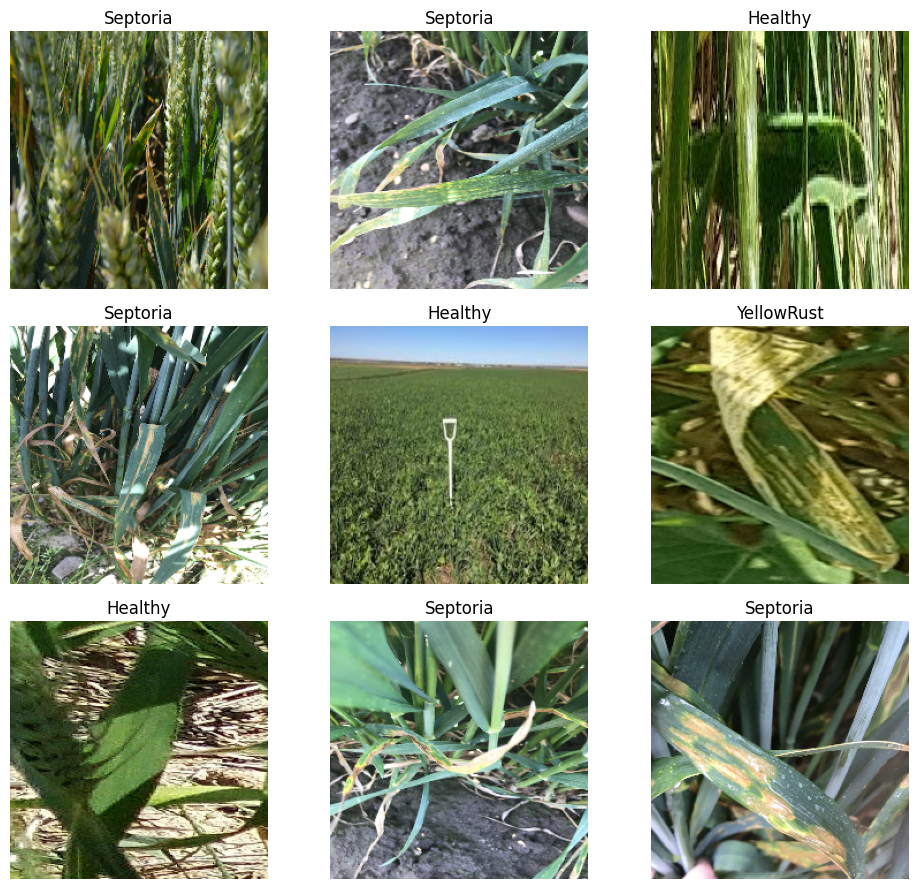

In [11]:
def show_samples(df, n=9):
    samples = df.sample(min(n, len(df)), random_state=SEED)
    rows = int(np.ceil(n / 3))
    plt.figure(figsize=(10, 3 * rows))
    for i, (_, row) in enumerate(samples.iterrows()):
        img = tf.io.read_file(row['path'])
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        plt.subplot(rows, 3, i + 1)
        plt.imshow(tf.cast(img, tf.uint8))
        plt.title(row['class'])
        plt.axis('off')
    plt.tight_layout()

show_samples(df, n=9)


In [12]:
# Use .to_numpy() to ensure compatibility with sklearn
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    df['path'].to_numpy(),    # Changed from .values
    df['label'].to_numpy(),   # Changed from .values
    test_size=0.3,
    stratify=df['label'].to_numpy(), # Changed from .values
    random_state=SEED,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)
print('Train/Val/Test:', len(train_paths), len(val_paths), len(test_paths))


Train/Val/Test: 4166 893 893


In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.1),
], name='augmentation')


def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label


def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
test_ds = make_dataset(test_paths, test_labels, training=False)


In [25]:
# Optional: Offline Data Augmentation (Disabled by default)
# Note: Real-time data augmentation is already active in Cell 10 via tf.data.
# Saving augmented copies to disk is unnecessary and can cause dataset contamination.

SAVE_OFFLINE_AUGMENTED = False

if SAVE_OFFLINE_AUGMENTED:
    import shutil
    AUGMENTED_DIR = DATA_DIR / "augmented"
    AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)

    def generate_and_save_augmented_data(image_paths, labels, class_names, output_dir, augmentations_per_image=3, dataset_type='train'):
        """
        Generate augmented images and save them to separate folders by class.
        """
        dataset_dir = output_dir / dataset_type
        if dataset_dir.exists():
            shutil.rmtree(dataset_dir)
        dataset_dir.mkdir(parents=True, exist_ok=True)

        for class_idx, class_name in enumerate(class_names):
            class_dir = dataset_dir / class_name
            class_dir.mkdir(parents=True, exist_ok=True)

        print(f'Saving augmented {dataset_type} data...')

        for img_idx, (path, label) in enumerate(zip(image_paths, labels)):
            class_name = class_names[label]
            class_dir = dataset_dir / class_name

            img = tf.io.read_file(str(path))
            img = tf.image.decode_image(img, channels=3, expand_animations=False)
            img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
            img = tf.cast(img, tf.float32)

            for aug_idx in range(augmentations_per_image):
                augmented_img = data_augmentation(tf.expand_dims(img, 0), training=True)[0]
                augmented_img = tf.clip_by_value(augmented_img, 0, 255)
                augmented_img = tf.cast(augmented_img, tf.uint8)

                original_name = Path(path).stem
                output_filename = f'{original_name}_aug_{aug_idx}.jpg'
                output_path = class_dir / output_filename
                tf.keras.preprocessing.image.save_img(str(output_path), augmented_img.numpy())

            if (img_idx + 1) % max(1, len(image_paths) // 10) == 0:
                print(f'  Processed {img_idx + 1}/{len(image_paths)} images...')

        print(f'[OK] Augmented {dataset_type} data saved to: {dataset_dir}')
else:
    print("Offline disk augmentation is disabled. On-the-fly augmentation is active in Cell 10.")

Saving augmented train data...
  Processed 416/4166 images...
  Processed 832/4166 images...
  Processed 1248/4166 images...
  Processed 1664/4166 images...
  Processed 2080/4166 images...
  Processed 2496/4166 images...
  Processed 2912/4166 images...
  Processed 3328/4166 images...
  Processed 3744/4166 images...
  Processed 4160/4166 images...
✓ Augmented train data saved to C:\Users\it\Desktop\New folder (6)\wheats\data\augmented\train
Saving augmented val data...
  Processed 89/893 images...
  Processed 178/893 images...
  Processed 267/893 images...
  Processed 356/893 images...
  Processed 445/893 images...
  Processed 534/893 images...
  Processed 623/893 images...
  Processed 712/893 images...
  Processed 801/893 images...
  Processed 890/893 images...
✓ Augmented val data saved to C:\Users\it\Desktop\New folder (6)\wheats\data\augmented\val
Saving augmented test data...
  Processed 89/893 images...
  Processed 178/893 images...
  Processed 267/893 images...
  Processed 356/89

In [14]:
class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}
class_weights


{0: np.float64(1.0273736128236746),
 1: np.float64(1.1413698630136986),
 2: np.float64(1.013625304136253),
 3: np.float64(0.8050241545893719),
 4: np.float64(1.0848958333333334)}

In [15]:
def build_model(base_name, base_fn, preprocess_fn, num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = preprocess_fn(inputs)
    base = base_fn(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Stronger classification head
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    model = tf.keras.Model(inputs, outputs, name=f'{base_name}_transfer')

    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=INITIAL_LR),
        loss=loss_fn,
        metrics=['accuracy'],
    )
    return model, base


In [16]:
def train_head_only(
    model,
    train_ds,
    val_ds,
    class_weights,
    initial_epochs=INITIAL_EPOCHS,
    initial_lr=INITIAL_LR,
    patience=PATIENCE,
    checkpoint_path=None,
):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=max(2, patience//2), min_lr=1e-6),
    ]

    if checkpoint_path is not None:
        callbacks.append(
            tf.keras.callbacks.ModelCheckpoint(
                filepath=str(checkpoint_path),
                monitor='val_loss',
                save_best_only=True,
                save_weights_only=False,
                verbose=1,
            )
        )

    # Train only the classifier head (base remains frozen)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy'],
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=initial_epochs,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1,
    )

    return history


In [17]:
RESUME_FROM_CHECKPOINT = False

In [18]:
vgg_model = tf.keras.models.load_model("./artifacts/VGG16_best.keras")
mobile_model = tf.keras.models.load_model("./artifacts/MobileNetV2_best.keras")
resnet_model = tf.keras.models.load_model("./artifacts/ResNet50_best.keras")

In [19]:
model_configs = {
    'VGG16': (tf.keras.applications.VGG16, tf.keras.applications.vgg16.preprocess_input),
    'MobileNetV2': (tf.keras.applications.MobileNetV2, tf.keras.applications.mobilenet_v2.preprocess_input),
    'ResNet50': (tf.keras.applications.ResNet50, tf.keras.applications.resnet50.preprocess_input),
}

results = []
histories = {}
saved_paths = {}

ARTIFACTS_DIR = Path(r"C:\Users\it\Desktop\New folder (6)\wheats\artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

num_classes = len(class_names)



In [20]:
for name, (base_fn, preprocess_fn) in model_configs.items():
    tf.keras.backend.clear_session()
    print(f'Training {name} (base frozen)')

    ckpt_path = ARTIFACTS_DIR / f'{name}_best.keras'
    model = None
    

    # If you want to resume training from a previous checkpoint, set RESUME_FROM_CHECKPOINT = True
    if RESUME_FROM_CHECKPOINT and ckpt_path.exists():
        try:
            loaded_model = tf.keras.models.load_model(ckpt_path)
            if loaded_model.output_shape[-1] == num_classes:
                print(f'Resuming from checkpoint: {ckpt_path}')
                model = loaded_model
            else:
                print(
                    f'WARNING: checkpoint {ckpt_path} was trained for {loaded_model.output_shape[-1]} classes, '
                    f'but the current dataset has {num_classes} classes. '
                    f'Skipping this checkpoint and rebuilding the model from scratch for {name}.'
                )
        except Exception as exc:
            print(
                f'WARNING: failed to load checkpoint {ckpt_path} ({exc}). '
                f'Rebuilding the model from scratch for {name}.'
            )

    # Otherwise start fresh from the pretrained base
    if model is None:
        model, _base = build_model(name, base_fn, preprocess_fn, num_classes)

    history = train_head_only(
        model,
        train_ds,
        val_ds,
        class_weights,
        checkpoint_path=ckpt_path,
    )
    histories[name] = history

    # Load best checkpoint if available
    if ckpt_path.exists():
        model = tf.keras.models.load_model(ckpt_path)

    y_prob = model.predict(test_ds)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.array(test_labels)

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    results.append({
        'model': name,
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
    })

    model_path = ARTIFACTS_DIR / f'{name}.keras'
    model.save(model_path)
    saved_paths[name] = model_path
    print(f'Saved: {model_path}')



Training VGG16 (base frozen)
Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6296 - loss: 1.0645
Epoch 1: val_loss improved from None to 0.43182, saving model to C:\Users\it\Desktop\New folder (6)\wheats\artifacts\VGG16_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.7374 - loss: 0.7645 - val_accuracy: 0.8623 - val_loss: 0.4318 - learning_rate: 0.0010
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8525 - loss: 0.4110
Epoch 2: val_loss improved from 0.43182 to 0.28166, saving model to C:\Users\it\Desktop\New folder (6)\wheats\artifacts\VGG16_best.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.8519 - loss: 0.4112 - val_accuracy: 0.9071 - val_loss: 0.2817 - learning_rate: 0.0010
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8838 - loss: 0.3149
Epoch 3: val_loss improved from 0.28166 to 0.23758, saving model to C:\Users\it\Desktop\New folder (6)\wheats\artifacts\VGG16_best.keras
131/131 ━━━━━━━━━━━━━━━

In [21]:
results_df = pd.DataFrame(results)
print(results_df.columns)
results_df


Index(['model', 'accuracy', 'precision', 'recall', 'f1_score'], dtype='object')


,model,accuracy,precision,recall,f1_score
0,VGG16,0.947368,0.947741,0.947368,0.947177
1,MobileNetV2,0.951848,0.952652,0.951848,0.951793
2,ResNet50,0.970885,0.971175,0.970885,0.970825


In [22]:
train_val_results = []
for name, hist in histories.items():
    h = hist.history
    train_acc = h.get('accuracy', [None])[-1]
    val_acc = h.get('val_accuracy', [None])[-1]
    best_val_epoch = int(np.argmax(h['val_accuracy'])) + 1 if 'val_accuracy' in h else None
    best_val_acc = float(max(h['val_accuracy'])) if 'val_accuracy' in h else None
    train_val_results.append({
        'model': name,
        'train_accuracy_last_epoch': train_acc,
        'val_accuracy_last_epoch': val_acc,
        'best_val_accuracy': best_val_acc,
        'best_val_epoch': best_val_epoch,
    })

train_val_df = pd.DataFrame(train_val_results).sort_values('model').reset_index(drop=True)
train_val_df

,model,train_accuracy_last_epoch,val_accuracy_last_epoch,best_val_accuracy,best_val_epoch
0,MobileNetV2,0.991359,0.968645,0.968645,19
1,ResNet50,0.990879,0.979843,0.979843,24
2,VGG16,0.986798,0.955207,0.960806,28


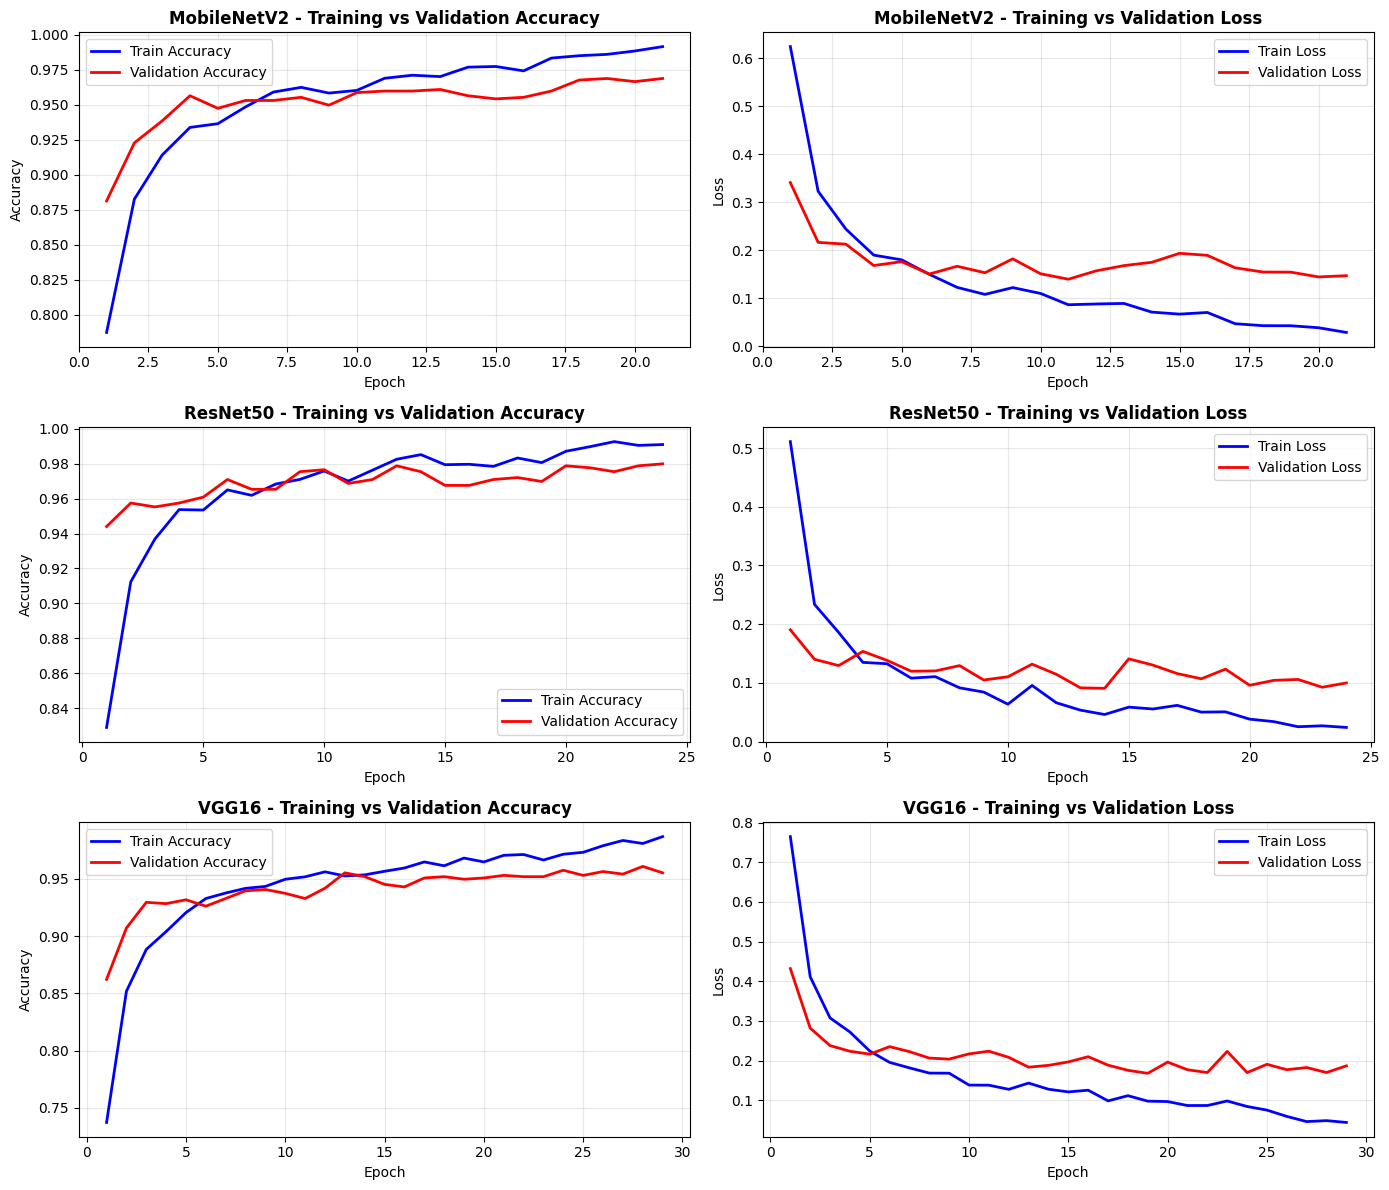

In [23]:
# Individual accuracy and loss plots for each model
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, (name, hist) in enumerate(sorted(histories.items())):
    h = hist.history
    epochs = range(1, len(h['accuracy']) + 1)
    
    # Plot accuracy
    axes[idx, 0].plot(epochs, h['accuracy'], 'b-', label='Train Accuracy', linewidth=2)
    axes[idx, 0].plot(epochs, h['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[idx, 0].set_title(f'{name} - Training vs Validation Accuracy', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Accuracy')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Plot loss
    axes[idx, 1].plot(epochs, h['loss'], 'b-', label='Train Loss', linewidth=2)
    axes[idx, 1].plot(epochs, h['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[idx, 1].set_title(f'{name} - Training vs Validation Loss', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Loss')
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

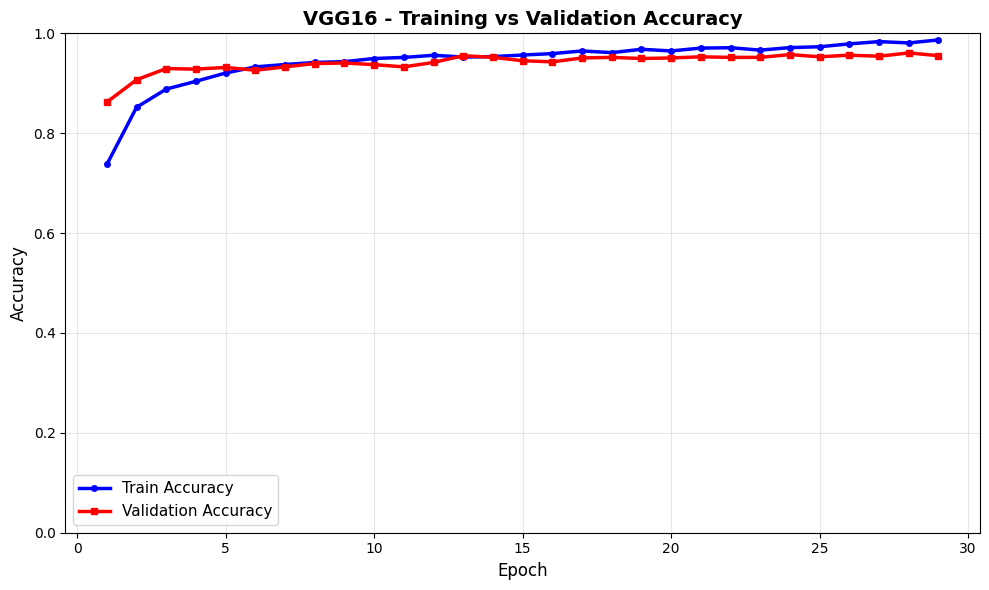

VGG16 - Train Accuracy (last epoch): 0.9868
VGG16 - Validation Accuracy (last epoch): 0.9552
VGG16 - Best Validation Accuracy: 0.9608 at epoch 28


In [24]:
# VGG16 - Train and Validation Accuracy
vgg_hist = histories['VGG16'].history
epochs_vgg = range(1, len(vgg_hist['accuracy']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_vgg, vgg_hist['accuracy'], 'b-', label='Train Accuracy', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs_vgg, vgg_hist['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2.5, marker='s', markersize=4)
plt.title('VGG16 - Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.0])
plt.tight_layout()
plt.show()

print(f"VGG16 - Train Accuracy (last epoch): {vgg_hist['accuracy'][-1]:.4f}")
print(f"VGG16 - Validation Accuracy (last epoch): {vgg_hist['val_accuracy'][-1]:.4f}")
print(f"VGG16 - Best Validation Accuracy: {max(vgg_hist['val_accuracy']):.4f} at epoch {np.argmax(vgg_hist['val_accuracy']) + 1}")

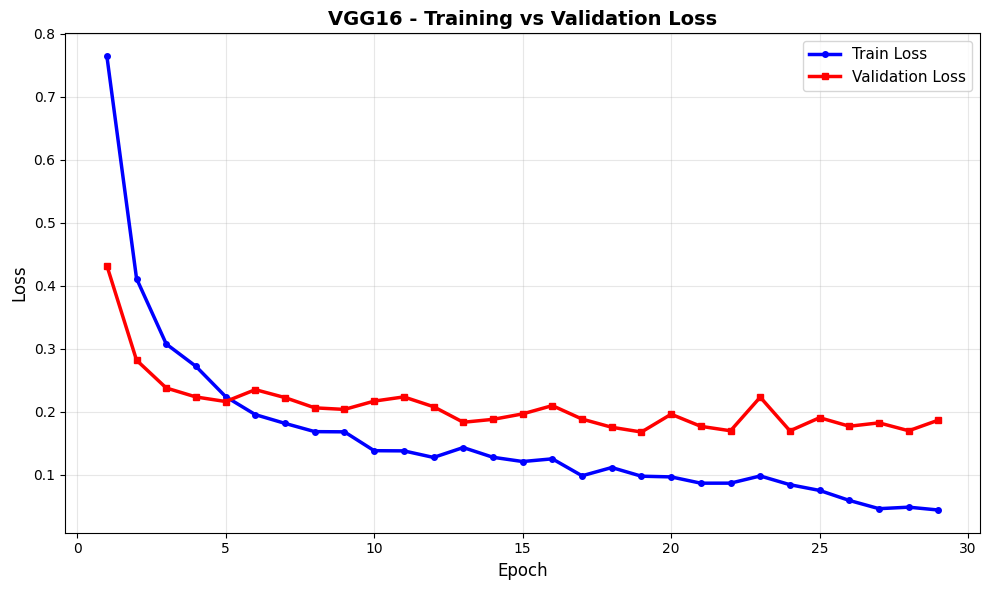

VGG16 - Train Loss (last epoch): 0.0439
VGG16 - Validation Loss (last epoch): 0.1866
VGG16 - Best Validation Loss: 0.1677 at epoch 19


In [25]:
# VGG16 - Training vs Validation Loss
vgg_hist = histories['VGG16'].history
epochs_vgg = range(1, len(vgg_hist['loss']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_vgg, vgg_hist['loss'], 'b-', label='Train Loss', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs_vgg, vgg_hist['val_loss'], 'r-', label='Validation Loss', linewidth=2.5, marker='s', markersize=4)
plt.title('VGG16 - Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"VGG16 - Train Loss (last epoch): {vgg_hist['loss'][-1]:.4f}")
print(f"VGG16 - Validation Loss (last epoch): {vgg_hist['val_loss'][-1]:.4f}")
print(f"VGG16 - Best Validation Loss: {min(vgg_hist['val_loss']):.4f} at epoch {np.argmin(vgg_hist['val_loss']) + 1}")


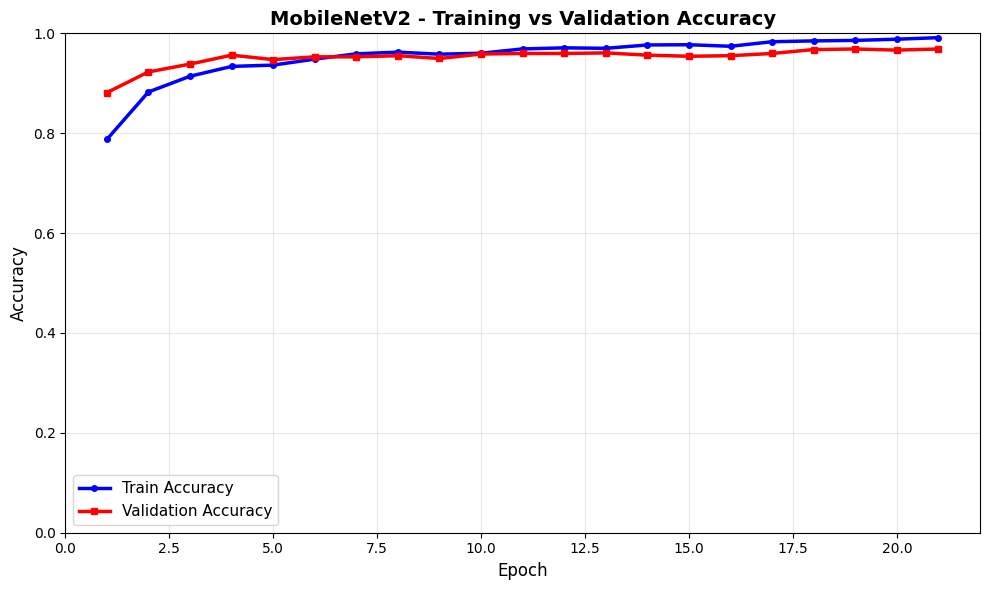

MobileNetV2 - Train Accuracy (last epoch): 0.9914
MobileNetV2 - Validation Accuracy (last epoch): 0.9686
MobileNetV2 - Best Validation Accuracy: 0.9686 at epoch 19


In [26]:
# MobileNetV2 - Train and Validation Accuracy
mobile_hist = histories['MobileNetV2'].history
epochs_mobile = range(1, len(mobile_hist['accuracy']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_mobile, mobile_hist['accuracy'], 'b-', label='Train Accuracy', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs_mobile, mobile_hist['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2.5, marker='s', markersize=4)
plt.title('MobileNetV2 - Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.0])
plt.tight_layout()
plt.show()

print(f"MobileNetV2 - Train Accuracy (last epoch): {mobile_hist['accuracy'][-1]:.4f}")
print(f"MobileNetV2 - Validation Accuracy (last epoch): {mobile_hist['val_accuracy'][-1]:.4f}")
print(f"MobileNetV2 - Best Validation Accuracy: {max(mobile_hist['val_accuracy']):.4f} at epoch {np.argmax(mobile_hist['val_accuracy']) + 1}")

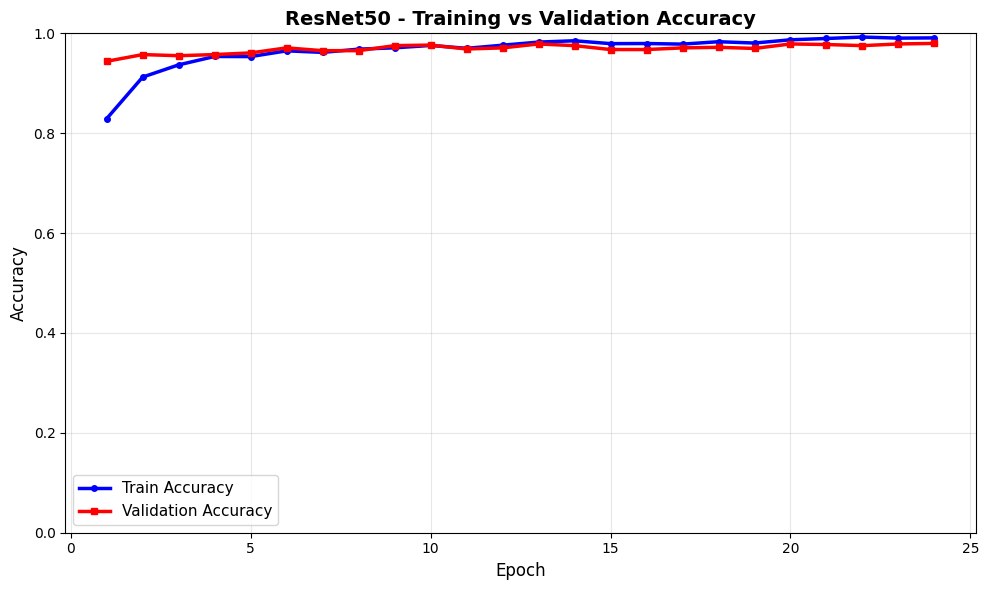

ResNet50 - Train Accuracy (last epoch): 0.9909
ResNet50 - Validation Accuracy (last epoch): 0.9798
ResNet50 - Best Validation Accuracy: 0.9798 at epoch 24


In [27]:
# ResNet50 - Train and Validation Accuracy
resnet_hist = histories['ResNet50'].history
epochs_resnet = range(1, len(resnet_hist['accuracy']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_resnet, resnet_hist['accuracy'], 'b-', label='Train Accuracy', linewidth=2.5, marker='o', markersize=4)
plt.plot(epochs_resnet, resnet_hist['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2.5, marker='s', markersize=4)
plt.title('ResNet50 - Training vs Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1.0])
plt.tight_layout()
plt.show()

print(f"ResNet50 - Train Accuracy (last epoch): {resnet_hist['accuracy'][-1]:.4f}")
print(f"ResNet50 - Validation Accuracy (last epoch): {resnet_hist['val_accuracy'][-1]:.4f}")
print(f"ResNet50 - Best Validation Accuracy: {max(resnet_hist['val_accuracy']):.4f} at epoch {np.argmax(resnet_hist['val_accuracy']) + 1}")

In [28]:
histories

{'VGG16': <keras.src.callbacks.history.History at 0x1720cdf0040>,
 'MobileNetV2': <keras.src.callbacks.history.History at 0x1723b63ad40>,
 'ResNet50': <keras.src.callbacks.history.History at 0x1723b45eef0>}

28/28 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step


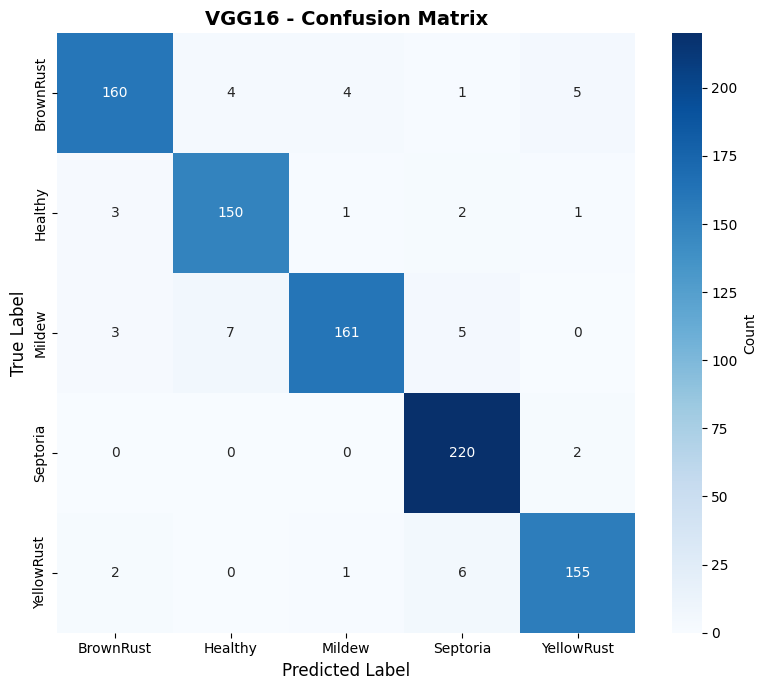

VGG16 - Classification Report:
              precision    recall  f1-score   support

   BrownRust       0.95      0.92      0.94       174
     Healthy       0.93      0.96      0.94       157
      Mildew       0.96      0.91      0.94       176
    Septoria       0.94      0.99      0.96       222
  YellowRust       0.95      0.95      0.95       164

    accuracy                           0.95       893
   macro avg       0.95      0.95      0.95       893
weighted avg       0.95      0.95      0.95       893



In [29]:
# VGG16 Confusion Matrix
vgg_model_cm = tf.keras.models.load_model(saved_paths['VGG16'])
y_prob_vgg = vgg_model_cm.predict(test_ds)
y_pred_vgg = np.argmax(y_prob_vgg, axis=1)
y_true = np.array(test_labels)

cm_vgg = confusion_matrix(y_true, y_pred_vgg)
plt.figure(figsize=(8, 7))
sns.heatmap(cm_vgg, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('VGG16 - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("VGG16 - Classification Report:")
print(classification_report(y_true, y_pred_vgg, target_names=class_names, zero_division=0))

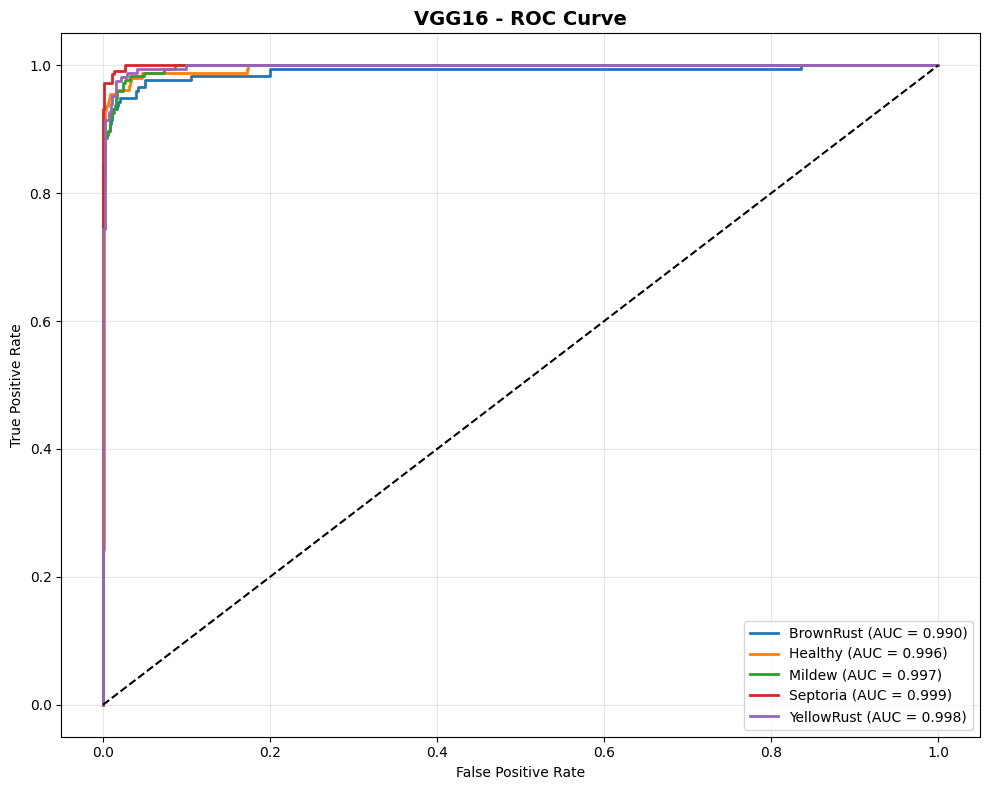

In [30]:
# VGG16 - ROC Curve (multiclass)
from pathlib import Path
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

if 'saved_paths' not in globals():
    ARTIFACTS_DIR = Path('artifacts')
    saved_paths = {
        'VGG16': ARTIFACTS_DIR / 'VGG16_best.keras' if (ARTIFACTS_DIR / 'VGG16_best.keras').exists() else ARTIFACTS_DIR / 'VGG16.keras',
        'MobileNetV2': ARTIFACTS_DIR / 'MobileNetV2_best.keras' if (ARTIFACTS_DIR / 'MobileNetV2_best.keras').exists() else ARTIFACTS_DIR / 'MobileNetV2.keras',
        'ResNet50': ARTIFACTS_DIR / 'ResNet50_best.keras' if (ARTIFACTS_DIR / 'ResNet50_best.keras').exists() else ARTIFACTS_DIR / 'ResNet50.keras',
        'DenseNet121': ARTIFACTS_DIR / 'DenseNet121_best.keras' if (ARTIFACTS_DIR / 'DenseNet121_best.keras').exists() else ARTIFACTS_DIR / 'DenseNet121.keras',
    }
    saved_path = saved_paths

# If y_prob_vgg has not been computed yet, load the model and compute predictions
if 'y_prob_vgg' not in globals():
    vgg_model_roc = tf.keras.models.load_model(saved_paths['VGG16'])
    y_prob_vgg = vgg_model_roc.predict(test_ds, verbose=0)

if 'y_true' not in globals():
    y_true = np.asarray(test_labels)

num_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Plot ROC curve for each disease class
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_vgg[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

# Random-classifier reference line
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.title("VGG16 - ROC Curves", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

28/28 ━━━━━━━━━━━━━━━━━━━━ 25s 838ms/step


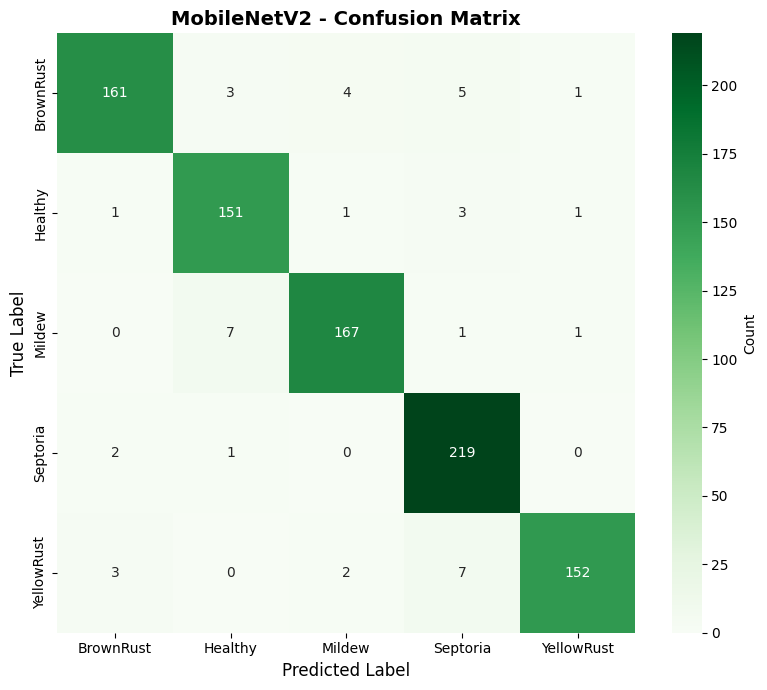

MobileNetV2 - Classification Report:
              precision    recall  f1-score   support

   BrownRust       0.96      0.93      0.94       174
     Healthy       0.93      0.96      0.95       157
      Mildew       0.96      0.95      0.95       176
    Septoria       0.93      0.99      0.96       222
  YellowRust       0.98      0.93      0.95       164

    accuracy                           0.95       893
   macro avg       0.95      0.95      0.95       893
weighted avg       0.95      0.95      0.95       893



In [31]:
# MobileNetV2 Confusion Matrix
mobile_model_cm = tf.keras.models.load_model(saved_paths['MobileNetV2'])
y_prob_mobile = mobile_model_cm.predict(test_ds)
y_pred_mobile = np.argmax(y_prob_mobile, axis=1)
y_true = np.array(test_labels)

cm_mobile = confusion_matrix(y_true, y_pred_mobile)
plt.figure(figsize=(8, 7))
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('MobileNetV2 - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("MobileNetV2 - Classification Report:")
print(classification_report(y_true, y_pred_mobile, target_names=class_names, zero_division=0))

28/28 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step


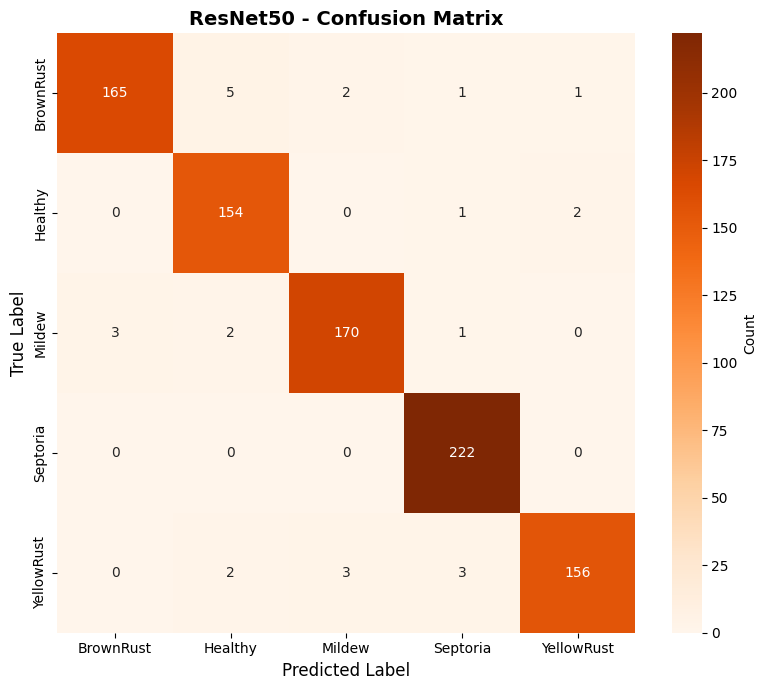

ResNet50 - Classification Report:
              precision    recall  f1-score   support

   BrownRust       0.98      0.95      0.96       174
     Healthy       0.94      0.98      0.96       157
      Mildew       0.97      0.97      0.97       176
    Septoria       0.97      1.00      0.99       222
  YellowRust       0.98      0.95      0.97       164

    accuracy                           0.97       893
   macro avg       0.97      0.97      0.97       893
weighted avg       0.97      0.97      0.97       893



In [32]:
# ResNet50 Confusion Matrix
resnet_model_cm = tf.keras.models.load_model(saved_paths['ResNet50'])
y_prob_resnet = resnet_model_cm.predict(test_ds)
y_pred_resnet = np.argmax(y_prob_resnet, axis=1)
y_true = np.array(test_labels)

cm_resnet = confusion_matrix(y_true, y_pred_resnet)
plt.figure(figsize=(8, 7))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('ResNet50 - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("ResNet50 - Classification Report:")
print(classification_report(y_true, y_pred_resnet, target_names=class_names, zero_division=0))


In [33]:
def predict_image(path, model, class_names):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = tf.expand_dims(img, axis=0)
    preds = model.predict(img)
    idx = int(np.argmax(preds[0]))
    return class_names[idx], float(preds[0][idx])

# Example usage:
# user_image_path = 'path/to/your/image.jpg'
# label, confidence = predict_image(user_image_path, best_model, class_names)
# print(label, confidence)


In [34]:
# Example usage:
# models = vgg_model, resnet_model, mobile_model
# vgg_model = tf.keras.models.load_model("./artifacts/VGG16_best.keras")
# mobile_model = tf.keras.models.load_model("./artifacts/MobileNetV2_best.keras")
# resnet_model = tf.keras.models.load_model("./artifacts/ResNet50_best.keras")
user_image_path = './data/Wheat Disease Dataset/Healthy/07901.jpeg'
label, confidence = predict_image(user_image_path, resnet_model, class_names)
print(label, confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Mildew 0.9998594522476196


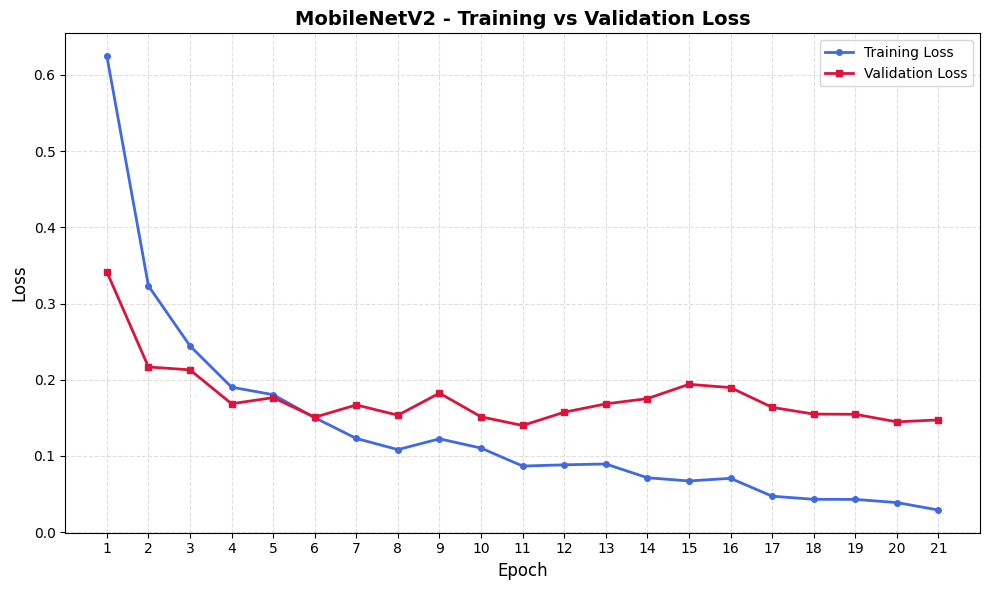

In [35]:
# MobileNetV2 - Training vs Validation Loss
mobile_hist = histories['MobileNetV2'].history
epochs_mobile = range(1, len(mobile_hist['loss']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_mobile, mobile_hist['loss'], color='royalblue', marker='o', markersize=4, linewidth=2, label='Training Loss')
plt.plot(epochs_mobile, mobile_hist['val_loss'], color='crimson', marker='s', markersize=4, linewidth=2, label='Validation Loss')
plt.title('MobileNetV2 - Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(1, len(mobile_hist['loss']) + 1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

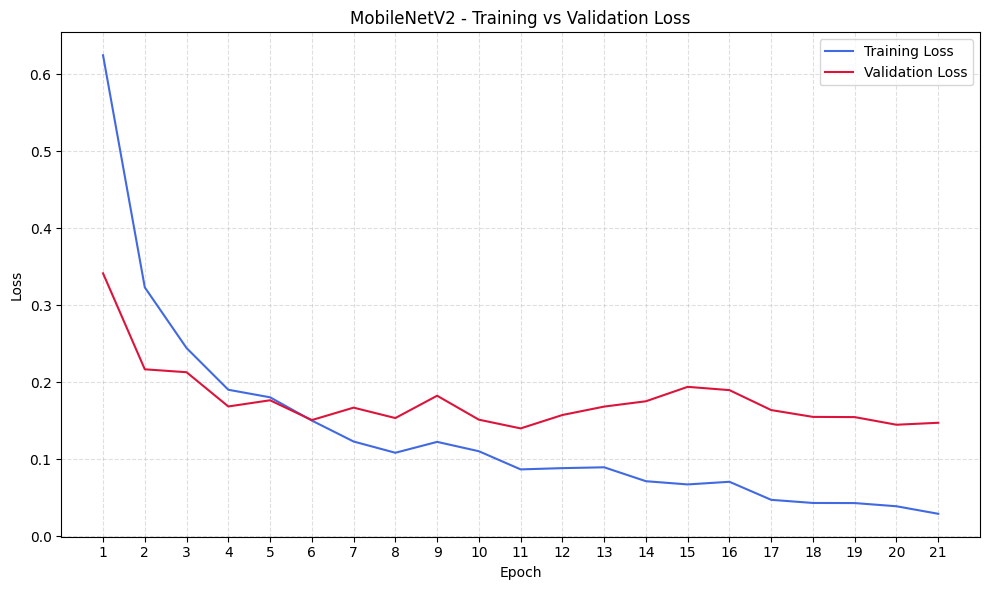

In [36]:
# MobileNetV2 - Training vs Validation Loss
if 'MobileNetV2' not in histories:
    raise ValueError("MobileNetV2 has not been trained yet. Run the training cell first.")

mobile_hist = histories['MobileNetV2'].history
epochs_mobile = range(1, len(mobile_hist['loss']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_mobile, mobile_hist['loss'], label='Training Loss', color='royalblue')
plt.plot(epochs_mobile, mobile_hist['val_loss'], label='Validation Loss', color='crimson')

plt.title('MobileNetV2 - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, len(mobile_hist['loss']) + 1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

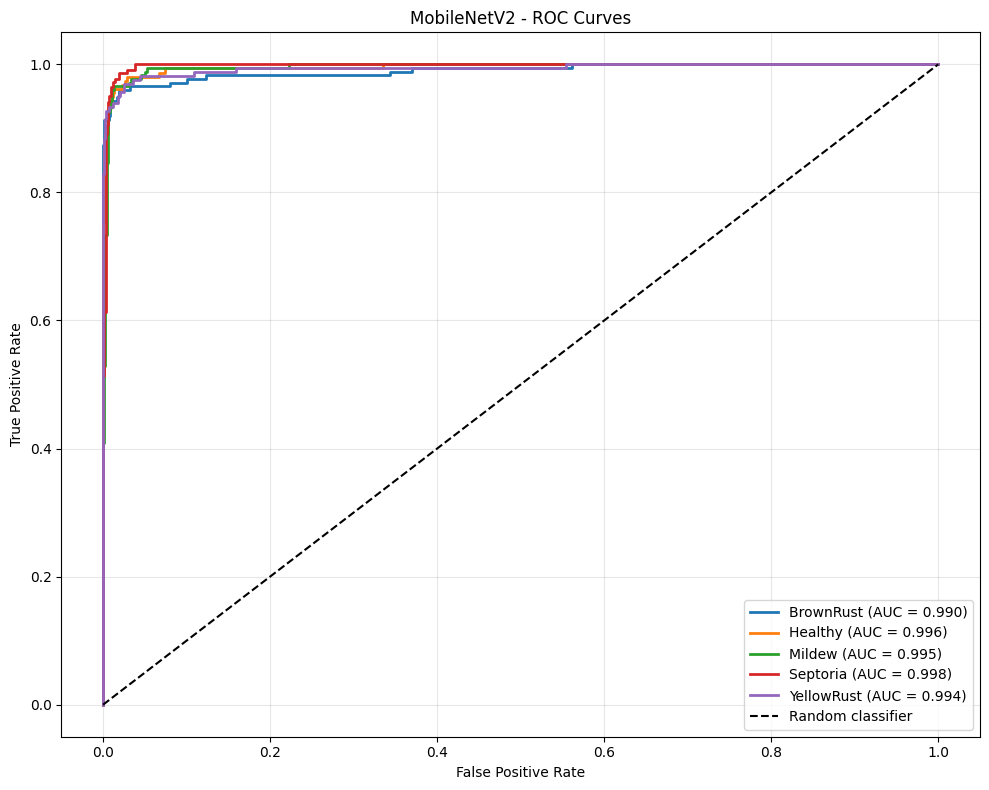

In [37]:
# MobileNetV2 - ROC Curve (multiclass)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Load the best MobileNetV2 model
mobile_model = tf.keras.models.load_model(saved_paths["MobileNetV2"])

# Get predicted class probabilities
y_prob_mobile = mobile_model.predict(test_ds, verbose=0)

# True labels and one-hot/binary representation
y_true = np.asarray(test_labels)
num_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Plot ROC curve for each disease class
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_mobile[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

# Random-classifier reference line
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.title("MobileNetV2 - ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

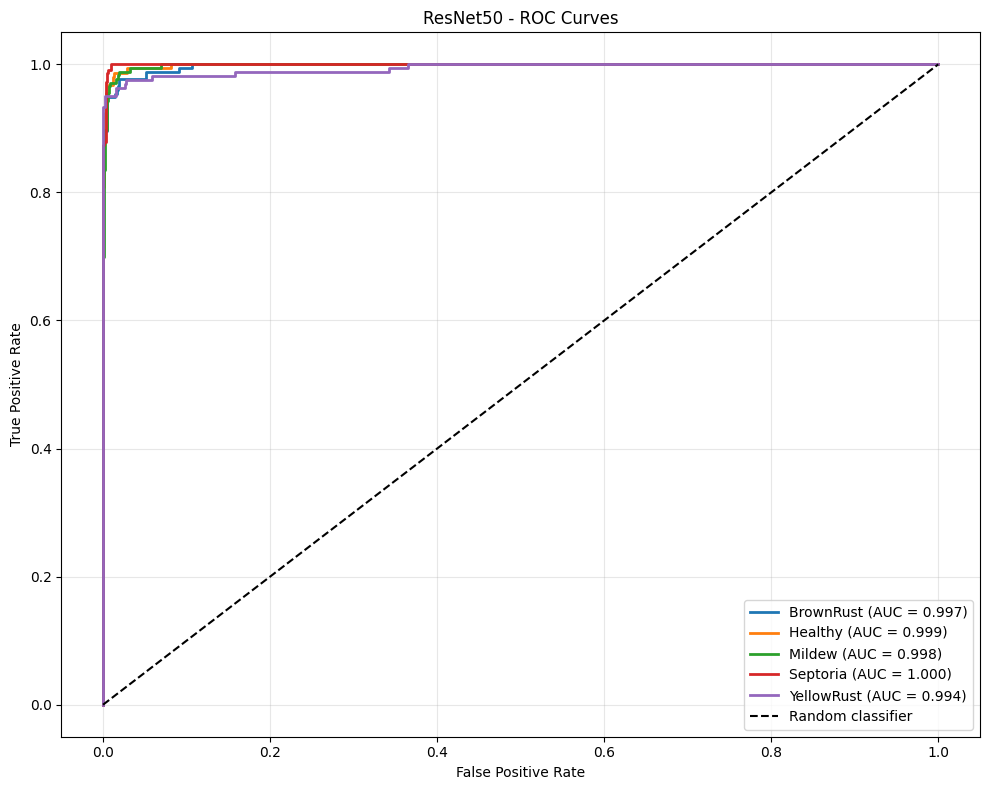

In [38]:
# ResNet50 - ROC Curve (multiclass)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Load the best trained ResNet50 model
resnet_model = tf.keras.models.load_model(saved_paths["ResNet50"])

# Get class probabilities for the test images
y_prob_resnet = resnet_model.predict(test_ds, verbose=0)

# Convert true numeric labels to one-vs-rest binary labels
y_true = np.asarray(test_labels)
num_classes = len(class_names)
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Plot one ROC curve per class
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_resnet[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

# Random classifier baseline
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.title("ResNet50 - ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()